In [1]:
import math
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import os
import random
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.utils import to_undirected
from torch_geometric.nn import GATConv
from torch_geometric.nn import GATv2Conv
from sklearn.preprocessing import StandardScaler

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

def set_seed(seed: int = 42):
    os.environ['PYTHONHASHSEED'] = str(seed)
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark     = False
set_seed(8386)

#### 1. We load ratings dataset and re-map userId and movieId into another map to get distinct id for each movie and user

In [2]:
ratings = pd.read_csv('ml-latest-small/ratings.csv')
movies = pd.read_csv("ml-latest-small/movies.csv")
ratings = ratings.merge(movies[['movieId', 'genres']], on='movieId', how='left')

user_ids, movie_ids = ratings.userId.unique(), ratings.movieId.unique()
u_map = {uid:i for i, uid in enumerate(user_ids)}
m_map = {mid:i+len(u_map) for i, mid in enumerate(movie_ids)}
ratings['u_idx'] = ratings.userId.map(u_map)
ratings['m_idx'] = ratings.movieId.map(m_map)

num_users, num_movies = len(u_map), len(m_map)
num_nodes = num_users + num_movies
print(f"num_users: {num_users}")
print(f"num_movies: {num_movies}")
print(f"num_nodes: {num_nodes}")
ratings.head(3)

num_users: 610
num_movies: 9724
num_nodes: 10334


,userId,movieId,rating,timestamp,genres,u_idx,m_idx
0,1,1,4.0,964982703,Adventure|Animation|Children|Comedy|Fantasy,0,610
1,1,3,4.0,964981247,Comedy|Romance,0,611
2,1,6,4.0,964982224,Action|Crime|Thriller,0,612


#### 2. We build an undirected edge index and its label (rating)

In [3]:
u = torch.tensor(ratings.u_idx.values, dtype=torch.long)
m = torch.tensor(ratings.m_idx.values, dtype=torch.long)
edge_index = torch.stack([u, m], dim=0)
edge_index = to_undirected(edge_index)
edge_label = torch.tensor(ratings.rating.values, dtype=torch.float)
edge_label = torch.cat([edge_label, edge_label], dim=0)
print(f"edge_index: {edge_index}")
print(f"edge_index.size: {edge_index.size()}")
print(f"edge_label: {edge_label}")
print(f"edge_label.size: {edge_label.size()}")

edge_index: tensor([[    0,     0,     0,  ..., 10331, 10332, 10333],
        [  610,   611,   612,  ...,   609,   609,   609]])
edge_index.size: torch.Size([2, 201672])
edge_label: tensor([4., 4., 4.,  ..., 5., 5., 3.])
edge_label.size: torch.Size([201672])


#### 3. Splitting the dataset by 80/10/10

In [4]:
E = edge_label.size(0)
perm = torch.randperm(E) # Shuffle indices of all edges
n1,n2 = int(0.8*E), int(0.9*E) # mark the idx of 80th and 90th percentile
mask = lambda idx: torch.zeros(E, dtype=torch.bool).scatter_(0, idx, True) # lambda to mask true
train_mask = mask(perm[:n1])
val_mask   = mask(perm[n1:n2])
test_mask  = mask(perm[n2:])

In [5]:
sum(train_mask)

tensor(161337)

#### 4. Node features: 
- Node's degree
- PageRank
- Betweenness
- Closeness
- Eigenvector

In [7]:
G_full = nx.Graph()
G_full.add_nodes_from(range(num_nodes))
G_full.add_edges_from(edge_index.t().tolist())   # all edges, train+val+test

deg_dict = dict(G_full.degree())
pr_dict  = nx.pagerank(G_full, alpha=0.85)
bc_dict  = nx.betweenness_centrality(G_full, normalized=True)
cc_dict  = nx.closeness_centrality(G_full)
ec_dict = nx.eigenvector_centrality(G_full, max_iter=2000, tol=1e-4)

def dict_to_col(d):
    return torch.tensor([d[i] for i in range(num_nodes)], dtype=torch.float).unsqueeze(1)

deg_col = dict_to_col(deg_dict)
pr_col  = dict_to_col(pr_dict)
bc_col  = dict_to_col(bc_dict)
cc_col  = dict_to_col(cc_dict)
ec_col  = dict_to_col(ec_dict)

node_features = torch.cat([deg_col, pr_col, bc_col, cc_col, ec_col], dim=1)
print(f"node_features.shape: {node_features.shape}")
node_features

node_features.shape: torch.Size([10334, 5])


tensor([[2.3200e+02, 8.6665e-04, 8.5432e-04, 3.4489e-01, 3.1419e-02],
        [2.9000e+01, 1.3435e-04, 2.0433e-04, 3.3343e-01, 3.4000e-03],
        [3.9000e+01, 2.5354e-04, 8.6362e-04, 3.3167e-01, 2.4466e-03],
        ...,
        [1.0000e+00, 2.0100e-05, 0.0000e+00, 2.7102e-01, 6.0861e-04],
        [1.0000e+00, 2.0100e-05, 0.0000e+00, 2.7102e-01, 6.0861e-04],
        [1.0000e+00, 2.0100e-05, 0.0000e+00, 2.7102e-01, 6.0861e-04]])

#### 5. Node's features scaling by train dataset only

In [8]:
src, dst = edge_index[:, train_mask]
train_nodes = torch.unique(torch.cat([src, dst])).cpu().numpy()
X = node_features.cpu().numpy()
scaler = StandardScaler()
scaler.fit(X[train_nodes, :])   # we use training dataset to get a scaler
X_scaled = scaler.transform(X)  # apply scaler for all datapoints

node_features_scaled = torch.tensor(X_scaled, dtype=torch.float, device=device)
node_features_scaled

tensor([[ 2.7014,  1.8367,  0.2132,  1.1571,  3.0589],
        [ 0.1172,  0.0871, -0.0104,  0.8615, -0.1428],
        [ 0.2445,  0.3718,  0.2164,  0.8163, -0.2518],
        ...,
        [-0.2392, -0.1859, -0.0807, -0.7477, -0.4618],
        [-0.2392, -0.1859, -0.0807, -0.7477, -0.4618],
        [-0.2392, -0.1859, -0.0807, -0.7477, -0.4618]])

#### 6. Assemble data

In [9]:
data = Data(
  x          = node_features_scaled,    # [num_nodes × num_node_features]
  edge_index = edge_index,       # [2 × num_edges] COO format
  edge_label = edge_label,       # [num_edges] your real‑valued targets
  train_mask = train_mask,       # [num_edges] bool mask for training edges
  val_mask   = val_mask,         # [num_edges] bool mask for validation
  test_mask  = test_mask         # [num_edges] bool mask for testing
)
print(data)

Data(x=[10334, 5], edge_index=[2, 201672], edge_label=[201672], train_mask=[201672], val_mask=[201672], test_mask=[201672])


#### 7. Define GAT architecture

- in_dim is the size of each node’s input feature vector (e.g. degree, metadata, embeddings, etc.)
- just like in the textbook, for multi-head attention, the rule of thumb is that we concat multi-head hidden embeddings for hidden layer (gat1) and taking average for the last layer (gat2) 

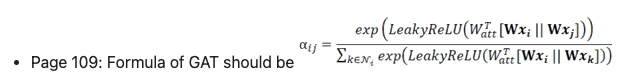

In [10]:
### from textbook
### however, it does not work since textbook focus on node classification where as our problem is more like edge-prediction

# def accuracy(y_pred, y_true):
#     return torch.sum(y_pred == y_true) / len(y_true)

# class GAT(nn.Module):
#     def __init__(self, in_dim, hidden_dim=32, heads=4):
#         super().__init__()
#         # GAT‑v2 layers
#         self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, concat=True)
#         self.gat2 = GATv2Conv(hidden_dim*heads, in_dim, heads=1,   concat=False)

#     def forward(self, x, edge_index):
#         h = F.dropout(x, p=0.6, training=self.training)
#         6. 7. Implementing a GAT in PyTorch Geometric 115
#         h = self.gat1(h, edge_index)
#         h = F.elu(h)
#         h = F.dropout(h, p=0.6, training=self.training)
#         h = self.gat2(h, edge_index)
#         return F.log_softmax(h, dim=1)

#     def fit(self, data, epochs):
#         criterion = torch.nn.CrossEntropyLoss()
#         optimizer = torch.optim.Adam(self.parameters(), lr=0.01, weight_decay=0.01)
#         self.train()
#         for epoch in range(epochs+1):
#             optimizer.zero_grad()
#             out = self(data.x, data.edge_index)
#             loss = criterion(out[data.train_mask], data.y[data.train_mask])
#             acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])
#             loss.backward()
#             optimizer.step()
#             if(epoch % 20 == 0):
#                 val_loss = criterion(out[data.val_mask], data.y[data.val_mask])
#                 val_acc = accuracy(out[data.val_mask].argmax(dim=1), data.y[data.val_mask])
#                 print(f'Epoch {epoch:>3} | Train Loss: {loss:.3f} | Train Acc: {acc*100:>5.2f}% | Val Loss: {val_loss:.2f} | Val Acc: {val_acc*100:.2f}%')


#     @torch.no_grad()
#     def test(self, data):
#         self.eval()
#         out = self(data.x, data.edge_index)
#         acc = accuracy(out.argmax(dim=1)[data.test_mask],
#         data.y[data.test_mask])
#         return acc

Summary:
- Run two GATv2Conv layers (with an ELU after the first) to get learned node embeddings.
- For each edge, take its two endpoint embeddings, concatenate them, run through a little 2‑layer MLP (lin1→ReLU→lin2), and that final linear output is predicted rating.

In [11]:
class GATv1Rec(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, heads=4):
        super().__init__()
        # GAT‑v2 layers
        self.gat1 = GATConv(in_dim, hidden_dim, heads=heads, concat=True) # just like in the textbook we concat multi-heads for first layer
        self.gat2 = GATConv(hidden_dim*heads, in_dim, heads=1,   concat=False) # and average out multi-heads in the last layer of GAT
        # regression head
        self.lin1 = nn.Linear(in_dim*2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # two GAT‑v2 message‑passing layers
        x = F.elu(self.gat1(x, edge_index))
        x = self.gat2(x, edge_index)

        # edge‑level prediction head
        src, dst = edge_index
        e = torch.cat([x[src], x[dst]], dim=1)   # [num_edges, 2*in_dim]
        h = F.relu(self.lin1(e))
        return self.lin2(h).squeeze()
    
class GATv2Rec(nn.Module):
    def __init__(self, in_dim, hidden_dim=32, heads=4):
        super().__init__()
        # GAT‑v2 layers 
        self.gat1 = GATv2Conv(in_dim, hidden_dim, heads=heads, concat=True)
        self.gat2 = GATv2Conv(hidden_dim*heads, in_dim, heads=1,   concat=False)
        # regression head
        self.lin1 = nn.Linear(in_dim*2, hidden_dim)
        self.lin2 = nn.Linear(hidden_dim, 1)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        # two GAT‑v2 message‑passing layers
        x = F.elu(self.gat1(x, edge_index))
        x = self.gat2(x, edge_index)

        # edge‑level prediction head
        src, dst = edge_index
        e = torch.cat([x[src], x[dst]], dim=1)   # [num_edges, 2*in_dim]
        h = F.relu(self.lin1(e))
        return self.lin2(h).squeeze()

#### 8. Training models using GAT V2

Epoch 010 | Train RMSE: 1.5108 | Val RMSE: 1.6143
Epoch 020 | Train RMSE: 1.2241 | Val RMSE: 1.2682
Epoch 030 | Train RMSE: 1.1690 | Val RMSE: 1.1762
Epoch 040 | Train RMSE: 1.1576 | Val RMSE: 1.1619
Epoch 050 | Train RMSE: 1.1431 | Val RMSE: 1.1489
Epoch 060 | Train RMSE: 1.1292 | Val RMSE: 1.1365
Epoch 070 | Train RMSE: 1.1186 | Val RMSE: 1.1262
Epoch 080 | Train RMSE: 1.1104 | Val RMSE: 1.1181
Epoch 090 | Train RMSE: 1.1034 | Val RMSE: 1.1111
Epoch 100 | Train RMSE: 1.0974 | Val RMSE: 1.1049
Epoch 110 | Train RMSE: 1.0920 | Val RMSE: 1.0995
Epoch 120 | Train RMSE: 1.0872 | Val RMSE: 1.0945
Epoch 130 | Train RMSE: 1.0827 | Val RMSE: 1.0899
Epoch 140 | Train RMSE: 1.0783 | Val RMSE: 1.0853
Epoch 150 | Train RMSE: 1.0737 | Val RMSE: 1.0805
Epoch 160 | Train RMSE: 1.0688 | Val RMSE: 1.0754
Epoch 170 | Train RMSE: 1.0640 | Val RMSE: 1.0704
Epoch 180 | Train RMSE: 1.0596 | Val RMSE: 1.0657
Epoch 190 | Train RMSE: 1.0558 | Val RMSE: 1.0617
Epoch 200 | Train RMSE: 1.0527 | Val RMSE: 1.0585


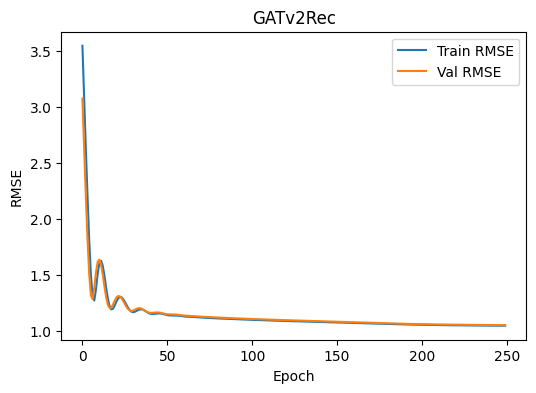

In [12]:
model = GATv2Rec(in_dim=data.x.size(1), hidden_dim=32, heads=4).to(device)
# model = GATv1Rec(in_dim=data.x.size(1), hidden_dim=32, heads=4).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = torch.nn.MSELoss()

data = data.to(device)
train_rmses, val_rmses = [], []
epochs = 500
threshold = 0.001
last_printed_val = float('inf')

for epoch in range(1, epochs + 1):
    model.train()
    opt.zero_grad()
    out = model(data)
    loss = loss_fn(out[data.train_mask], data.edge_label[data.train_mask])
    loss.backward()
    opt.step()
    train_rmses.append(math.sqrt(loss.item()))

    model.eval()
    with torch.no_grad():
        val_pred = model(data)
        v_loss = loss_fn(val_pred[data.val_mask], data.edge_label[data.val_mask])
        val_rmses.append(math.sqrt(v_loss.item()))

    if epoch % 10 == 0:
        curr_val = val_rmses[-1]
        curr_train = train_rmses[-1]
        print(f"Epoch {epoch:03d} | Train RMSE: {curr_train:.4f} | Val RMSE: {curr_val:.4f}")

        if abs(last_printed_val - curr_val) < threshold:
            print(f"Stopping early at epoch {epoch} (ΔVal RMSE < {threshold})")
            break
        last_printed_val = curr_val

model.eval()
with torch.no_grad():
    test_pred = model(data)
    t_loss = loss_fn(test_pred[data.test_mask], data.edge_label[data.test_mask])
    print(f"Test RMSE: {math.sqrt(t_loss.item()):.4f}")

plt.figure(figsize=(6, 4))
plt.plot(train_rmses, label='Train RMSE')
plt.plot(val_rmses, label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title(model.__class__.__name__)
plt.legend()
plt.show()

#### 9. Training models using GAT V1

Epoch 010 | Train RMSE: 2.9606 | Val RMSE: 2.8168
Epoch 020 | Train RMSE: 1.5207 | Val RMSE: 1.4338
Epoch 030 | Train RMSE: 1.1641 | Val RMSE: 1.1542
Epoch 040 | Train RMSE: 1.1624 | Val RMSE: 1.1560
Epoch 050 | Train RMSE: 1.0967 | Val RMSE: 1.1036
Epoch 060 | Train RMSE: 1.0868 | Val RMSE: 1.0909
Epoch 070 | Train RMSE: 1.0746 | Val RMSE: 1.0794
Epoch 080 | Train RMSE: 1.0715 | Val RMSE: 1.0763
Epoch 090 | Train RMSE: 1.0684 | Val RMSE: 1.0732
Epoch 100 | Train RMSE: 1.0662 | Val RMSE: 1.0709
Epoch 110 | Train RMSE: 1.0624 | Val RMSE: 1.0669
Epoch 120 | Train RMSE: 1.0562 | Val RMSE: 1.0600
Epoch 130 | Train RMSE: 1.0522 | Val RMSE: 1.0565
Epoch 140 | Train RMSE: 1.0510 | Val RMSE: 1.0552
Epoch 150 | Train RMSE: 1.0494 | Val RMSE: 1.0537
Epoch 160 | Train RMSE: 1.0482 | Val RMSE: 1.0526
Epoch 170 | Train RMSE: 1.0473 | Val RMSE: 1.0517
Stopping early at epoch 170 (ΔVal RMSE < 0.001)
Test RMSE: 1.0433


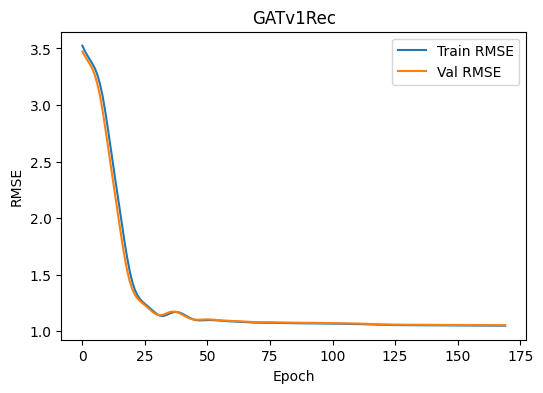

In [13]:
# model = GATv2Rec(in_dim=data.x.size(1), hidden_dim=32, heads=4).to(device)
model = GATv1Rec(in_dim=data.x.size(1), hidden_dim=32, heads=4).to(device)

opt = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
loss_fn = torch.nn.MSELoss()

data = data.to(device)
train_rmses, val_rmses = [], []
epochs = 500
threshold = 0.001
last_printed_val = float('inf')

for epoch in range(1, epochs + 1):
    model.train()
    opt.zero_grad()
    out = model(data)
    loss = loss_fn(out[data.train_mask], data.edge_label[data.train_mask])
    loss.backward()
    opt.step()
    train_rmses.append(math.sqrt(loss.item()))

    model.eval()
    with torch.no_grad():
        val_pred = model(data)
        v_loss = loss_fn(val_pred[data.val_mask], data.edge_label[data.val_mask])
        val_rmses.append(math.sqrt(v_loss.item()))

    if epoch % 10 == 0:
        curr_val = val_rmses[-1]
        curr_train = train_rmses[-1]
        print(f"Epoch {epoch:03d} | Train RMSE: {curr_train:.4f} | Val RMSE: {curr_val:.4f}")

        if abs(last_printed_val - curr_val) < threshold:
            print(f"Stopping early at epoch {epoch} (ΔVal RMSE < {threshold})")
            break
        last_printed_val = curr_val

model.eval()
with torch.no_grad():
    test_pred = model(data)
    t_loss = loss_fn(test_pred[data.test_mask], data.edge_label[data.test_mask])
    print(f"Test RMSE: {math.sqrt(t_loss.item()):.4f}")

plt.figure(figsize=(6, 4))
plt.plot(train_rmses, label='Train RMSE')
plt.plot(val_rmses, label='Val RMSE')
plt.xlabel('Epoch')
plt.ylabel('RMSE')
plt.title(model.__class__.__name__)
plt.legend()
plt.show()